# Catan RL — PPO vs 3× WeightedRandomPlayer (4-player)
Hardest baseline: 4-player game against 3 weighted heuristic opponents. Random chance = 25%.

In [1]:
import gymnasium
import numpy as np
import time
import torch
torch.distributions.Distribution.set_default_validate_args(False)

from sb3_contrib.common.maskable.policies import MaskableActorCriticPolicy
from sb3_contrib.common.wrappers import ActionMasker
from sb3_contrib.ppo_mask import MaskablePPO
from stable_baselines3.common.callbacks import BaseCallback
import catanatron_gym
from catanatron import Color
from catanatron.players.weighted_random import WeightedRandomPlayer

print("Imports OK")

/opt/homebrew/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (6.0.0dev0)/charset_normalizer (3.2.0) doesn't match a supported version!
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.5' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Imports OK


In [2]:
def mask_fn(env) -> np.ndarray:
    valid_actions = env.unwrapped.get_valid_actions()
    mask = np.zeros(env.action_space.n, dtype=bool)
    if len(valid_actions) > 0:
        mask[valid_actions] = True
    else:
        mask[:] = True
    return mask


class CatanLoggingCallback(BaseCallback):

    def __init__(self, log_freq=10_000, verbose=1):
        super().__init__(verbose)
        self.log_freq = log_freq
        self.start_time = None
        self.episode_rewards = []
        self.episode_lengths = []
        self.wins = 0
        self.losses = 0
        self.total_episodes = 0
        self._last_log_step = 0

    def _on_training_start(self):
        self.start_time = time.time()

    def _on_step(self) -> bool:
        infos = self.locals.get("infos", [])
        for info in infos:
            if "episode" in info:
                ep_reward = info["episode"]["r"]
                ep_length = info["episode"]["l"]
                self.episode_rewards.append(ep_reward)
                self.episode_lengths.append(ep_length)
                self.total_episodes += 1
                if ep_reward > 0:
                    self.wins += 1
                elif ep_reward < 0:
                    self.losses += 1

        if self.num_timesteps - self._last_log_step >= self.log_freq:
            if self.total_episodes > 0:
                self._print_stats()
            self._last_log_step = self.num_timesteps

        return True

    def _print_stats(self):
        elapsed = time.time() - self.start_time
        steps_per_sec = self.num_timesteps / elapsed
        total_steps = self.locals.get("total_timesteps", 1_000_000)
        remaining = total_steps - self.num_timesteps
        eta = remaining / steps_per_sec if steps_per_sec > 0 else 0

        recent_r = self.episode_rewards[-50:]
        recent_l = self.episode_lengths[-50:]
        recent_wins = sum(1 for r in recent_r if r > 0)

        eta_h, rem = divmod(int(eta), 3600)
        eta_m, eta_s = divmod(rem, 60)
        el_h, rem = divmod(int(elapsed), 3600)
        el_m, el_s = divmod(rem, 60)

        print(f"\n{'='*60}")
        print(f"  Step: {self.num_timesteps:,} / {total_steps:,} "
              f"({100*self.num_timesteps/total_steps:.1f}%)")
        print(f"  Elapsed: {el_h}h {el_m}m {el_s}s | "
              f"ETA: {eta_h}h {eta_m}m {eta_s}s")
        print(f"  Speed: {steps_per_sec:.0f} steps/s | "
              f"Episodes: {self.total_episodes}")
        print(f"  Overall win rate: {self.wins}/{self.total_episodes} "
              f"({100*self.wins/self.total_episodes:.1f}%)")
        print(f"  Last 50 ep: win {100*recent_wins/len(recent_r):.1f}% | "
              f"avg len {np.mean(recent_l):.0f} | "
              f"avg reward {np.mean(recent_r):.3f}")
        print(f"{'='*60}")

    def _on_training_end(self):
        elapsed = time.time() - self.start_time
        print(f"\n{'#'*60}")
        print(f"  TRAINING COMPLETE")
        print(f"  Total time: {elapsed/3600:.1f} hours")
        print(f"  Total episodes: {self.total_episodes}")
        print(f"  Final win rate: {100*self.wins/max(1,self.total_episodes):.1f}%")
        print(f"{'#'*60}")

In [3]:
TOTAL_TIMESTEPS = 1_000_000
SAVE_PATH = "catan_ppo_4p_weighted"

train_env = gymnasium.make(
    "catanatron-v1",
    config={
        "enemies": [
            WeightedRandomPlayer(Color.RED),
            WeightedRandomPlayer(Color.ORANGE),
            WeightedRandomPlayer(Color.WHITE),
        ],
    },
)
train_env = ActionMasker(train_env, mask_fn)

model = MaskablePPO(
    MaskableActorCriticPolicy,
    train_env,
    verbose=1,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.999,
    ent_coef=0.01,
    tensorboard_log="./catan_tb_4p_weighted/",
    policy_kwargs=dict(net_arch=[256, 256]),
)

print(f"Obs shape: {train_env.observation_space.shape}")
print(f"Action space: {train_env.action_space.n}")
print(f"Training for {TOTAL_TIMESTEPS:,} steps vs 3x WeightedRandom...\n")

callback = CatanLoggingCallback(log_freq=10_000)
model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback)
model.save(SAVE_PATH)
train_env.close()

print(f"\nModel saved to {SAVE_PATH}.zip")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Obs shape: (1002,)
Action space: 290
Training for 1,000,000 steps vs 3x WeightedRandom...

Logging to ./catan_tb_4p_weighted/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 155      |
|    ep_rew_mean     | -0.692   |
| time/              |          |
|    fps             | 1953     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 160        |
|    ep_rew_mean          | -0.833     |
| time/                   |            |
|    fps                  | 1190       |
|    iterations           | 2          |
|    time_elapsed         | 3          |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl           

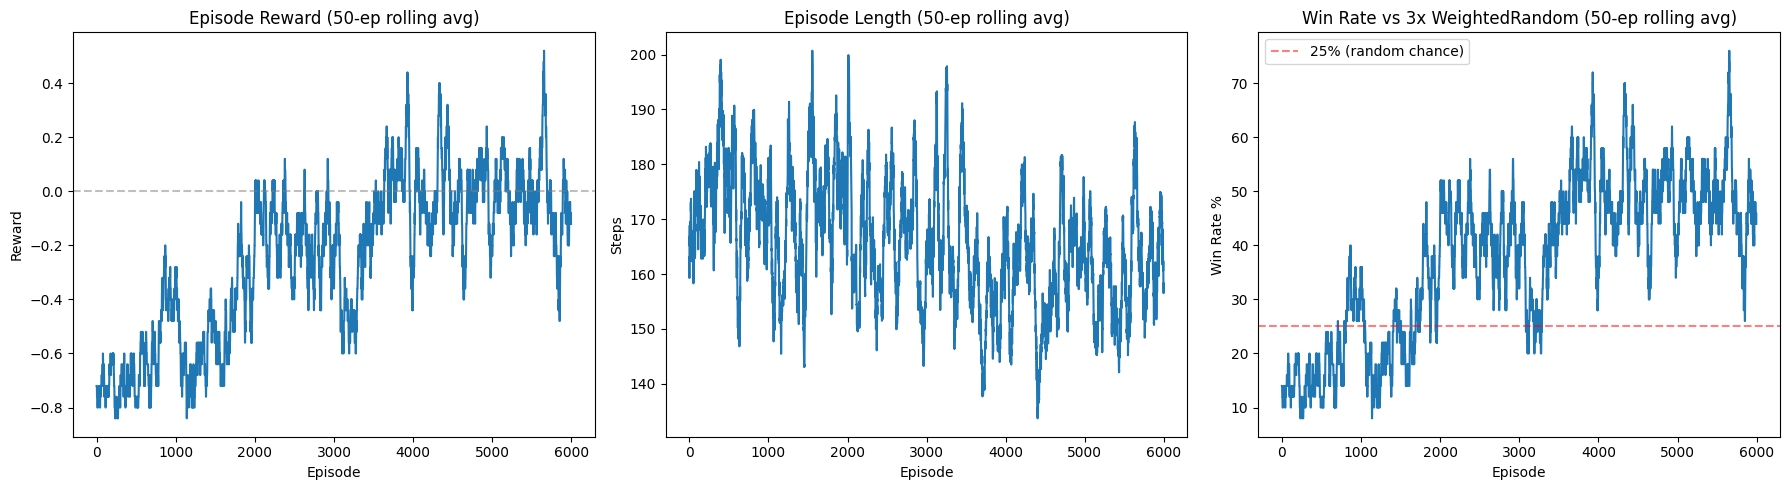

Total episodes: 6045
Final 50-ep win rate: 44.0%
Final 50-ep avg reward: -0.120


In [4]:
import matplotlib.pyplot as plt

rewards = callback.episode_rewards
lengths = callback.episode_lengths
window = 50

if len(rewards) >= window:
    smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
    smoothed_len = np.convolve(lengths, np.ones(window)/window, mode='valid')
    wins_binary = [1 if r > 0 else 0 for r in rewards]
    win_rate = np.convolve(wins_binary, np.ones(window)/window, mode='valid')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(smoothed)
    axes[0].set_title("Episode Reward (50-ep rolling avg)")
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Reward")
    axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

    axes[1].plot(smoothed_len)
    axes[1].set_title("Episode Length (50-ep rolling avg)")
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("Steps")

    axes[2].plot(100 * win_rate)
    axes[2].set_title("Win Rate vs 3x WeightedRandom (50-ep rolling avg)")
    axes[2].set_xlabel("Episode")
    axes[2].set_ylabel("Win Rate %")
    axes[2].axhline(y=25, color='red', linestyle='--', alpha=0.5, label='25% (random chance)')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    print(f"Total episodes: {len(rewards)}")
    print(f"Final 50-ep win rate: {100*win_rate[-1]:.1f}%")
    print(f"Final 50-ep avg reward: {smoothed[-1]:.3f}")
else:
    print(f"Only {len(rewards)} episodes, need {window} to plot")

In [5]:
SAVE_PATH = "catan_ppo_4p_weighted"
N_GAMES = 500

model = MaskablePPO.load(SAVE_PATH)

eval_env = gymnasium.make(
    "catanatron-v1",
    config={
        "enemies": [
            WeightedRandomPlayer(Color.RED),
            WeightedRandomPlayer(Color.ORANGE),
            WeightedRandomPlayer(Color.WHITE),
        ],
    },
)

wins, losses, draws = 0, 0, 0
ep_lengths = []
ep_rewards = []

print(f"Evaluating over {N_GAMES} games vs 3x WeightedRandom...")
start = time.time()

for i in range(N_GAMES):
    obs, info = eval_env.reset()
    done = False
    total_reward = 0
    steps = 0

    while not done:
        valid = eval_env.unwrapped.get_valid_actions()
        mask = np.zeros(eval_env.action_space.n, dtype=bool)
        if len(valid) > 0:
            mask[valid] = True
        else:
            mask[:] = True

        action, _ = model.predict(obs, action_masks=mask, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(int(action))
        total_reward += reward
        steps += 1
        done = terminated or truncated

    ep_lengths.append(steps)
    ep_rewards.append(total_reward)
    if total_reward > 0:
        wins += 1
    elif total_reward < 0:
        losses += 1
    else:
        draws += 1

    if (i + 1) % 50 == 0:
        elapsed = time.time() - start
        eta = (N_GAMES - i - 1) / ((i + 1) / elapsed)
        print(f"  [{i+1}/{N_GAMES}] Win rate: {100*wins/(i+1):.1f}% | ETA: {eta:.0f}s")

eval_env.close()
elapsed = time.time() - start

wr = wins / N_GAMES
z = 1.96
d = 1 + z**2 / N_GAMES
center = (wr + z**2 / (2 * N_GAMES)) / d
spread = z * np.sqrt((wr * (1 - wr) + z**2 / (4 * N_GAMES)) / N_GAMES) / d

print(f"\n{'='*60}")
print(f"  RESULTS vs 3x WeightedRandom ({N_GAMES} games, {elapsed:.0f}s)")
print(f"  Wins: {wins} | Losses: {losses} | Draws: {draws}")
print(f"  Win rate: {100*wr:.1f}%  (random chance: 25%)")
print(f"  95% CI:   [{100*max(0,center-spread):.1f}%, {100*min(1,center+spread):.1f}%]")
print(f"  Avg episode length: {np.mean(ep_lengths):.0f}")
print(f"  Avg reward: {np.mean(ep_rewards):.3f}")
print(f"{'='*60}")

Evaluating over 500 games vs 3x WeightedRandom...
  [50/500] Win rate: 58.0% | ETA: 24s
  [100/500] Win rate: 57.0% | ETA: 23s
  [150/500] Win rate: 55.3% | ETA: 21s
  [200/500] Win rate: 56.0% | ETA: 18s
  [250/500] Win rate: 55.6% | ETA: 15s
  [300/500] Win rate: 55.7% | ETA: 12s
  [350/500] Win rate: 54.9% | ETA: 9s
  [400/500] Win rate: 53.0% | ETA: 6s
  [450/500] Win rate: 53.8% | ETA: 3s
  [500/500] Win rate: 53.0% | ETA: 0s

  RESULTS vs 3x WeightedRandom (500 games, 30s)
  Wins: 265 | Losses: 235 | Draws: 0
  Win rate: 53.0%  (random chance: 25%)
  95% CI:   [48.6%, 57.3%]
  Avg episode length: 163
  Avg reward: 0.060
